# Marketing Campaign — Business Insights Report (EDA)

**Objective:** Explore and clean a marketing campaign dataset, visualize the customer/purchase funnel, evaluate channel and campaign performance, and recommend how marketing budget should be allocated across channels based on ROI.

This notebook focuses on **explanatory analysis** ("the why"), not predictive modeling.

**Dataset:** `marketing_campaign.csv` (2,240 customers, semicolon-delimited)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 50)


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep=';')
print(f"Shape: {df.shape}")
df.head()


Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()


In [3]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nDuplicate IDs: {df['ID'].duplicated().sum()}")


Missing values:
Income    24
dtype: int64

Duplicate rows: 0

Duplicate IDs: 0


## 2. Data Cleaning

Steps:
1. Impute the 24 missing `Income` values with the median (robust to outliers).
2. Remove implausible outliers: extreme income (> \$200k) and birth years implying age > 100.
3. Drop the 3 duplicate customer IDs.
4. Parse `Dt_Customer` to datetime.
5. Drop constant / uninformative columns (`Z_CostContact`, `Z_Revenue` are flat across all rows — kept separately for reference, not used as real cost data).

In [4]:
df_clean = df.copy()

# Duplicates
df_clean = df_clean.drop_duplicates(subset='ID', keep='first')

# Missing income -> median impute
df_clean['Income'] = df_clean['Income'].fillna(df_clean['Income'].median())

# Outlier removal
before = len(df_clean)
df_clean = df_clean[df_clean['Income'] < 200000]
df_clean = df_clean[df_clean['Year_Birth'] > 1940]
print(f"Removed {before - len(df_clean)} outlier rows")

# Parse dates
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], format='%Y-%m-%d')

print(f"Final clean shape: {df_clean.shape}")


Removed 5 outlier rows
Final clean shape: (2235, 29)


### Feature Engineering

In [5]:
ref_year = df_clean['Dt_Customer'].dt.year.max()

df_clean['Age'] = ref_year - df_clean['Year_Birth']
df_clean['Customer_Tenure_Days'] = (df_clean['Dt_Customer'].max() - df_clean['Dt_Customer']).dt.days
df_clean['Total_Kids'] = df_clean['Kidhome'] + df_clean['Teenhome']

spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_clean['Total_Spend'] = df_clean[spend_cols].sum(axis=1)

purchase_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_clean['Total_Purchases'] = df_clean[purchase_cols].sum(axis=1)

# Avoid divide-by-zero for average order value
df_clean['Avg_Order_Value'] = np.where(
    df_clean['Total_Purchases'] > 0,
    df_clean['Total_Spend'] / df_clean['Total_Purchases'],
    0
)

campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df_clean['Total_Campaigns_Accepted'] = df_clean[campaign_cols].sum(axis=1)
df_clean['Responded_Any'] = (df_clean['Total_Campaigns_Accepted'] > 0).astype(int)

df_clean[['Age', 'Total_Spend', 'Total_Purchases', 'Avg_Order_Value', 'Total_Campaigns_Accepted']].describe()


,Age,Total_Spend,Total_Purchases,Avg_Order_Value,Total_Campaigns_Accepted
count,2235.000000,2235.000000,2235.000000,2235.000000,2235.000000
mean,45.089038,606.187472,14.875168,33.272985,0.447427
std,11.689915,601.924861,7.678586,45.012803,0.891262
min,18.000000,5.000000,0.000000,0.000000,0.000000
25%,37.000000,69.000000,8.000000,9.650000,0.000000
50%,44.000000,397.000000,15.000000,23.375000,0.000000
75%,55.000000,1046.000000,21.000000,45.281773,1.000000
max,73.000000,2525.000000,44.000000,1679.000000,5.000000


## 3. Exploratory Data Analysis — Demographics & Spend

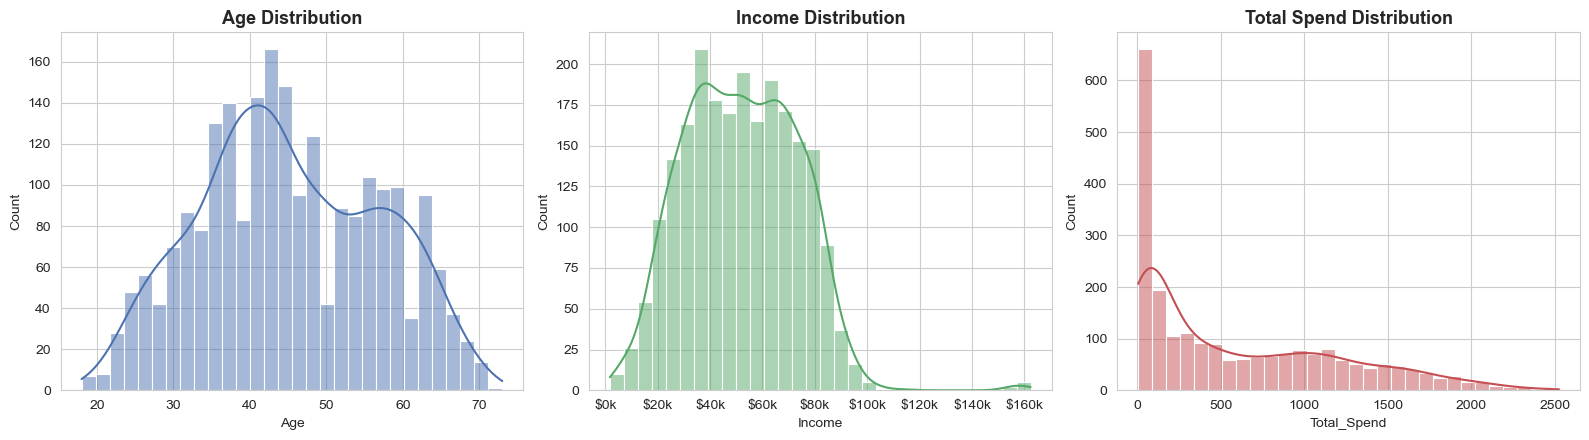

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df_clean['Age'], bins=30, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age Distribution')

sns.histplot(df_clean['Income'], bins=30, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Income Distribution')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

sns.histplot(df_clean['Total_Spend'], bins=30, kde=True, ax=axes[2], color='#C44E52')
axes[2].set_title('Total Spend Distribution')

plt.tight_layout()
plt.show()


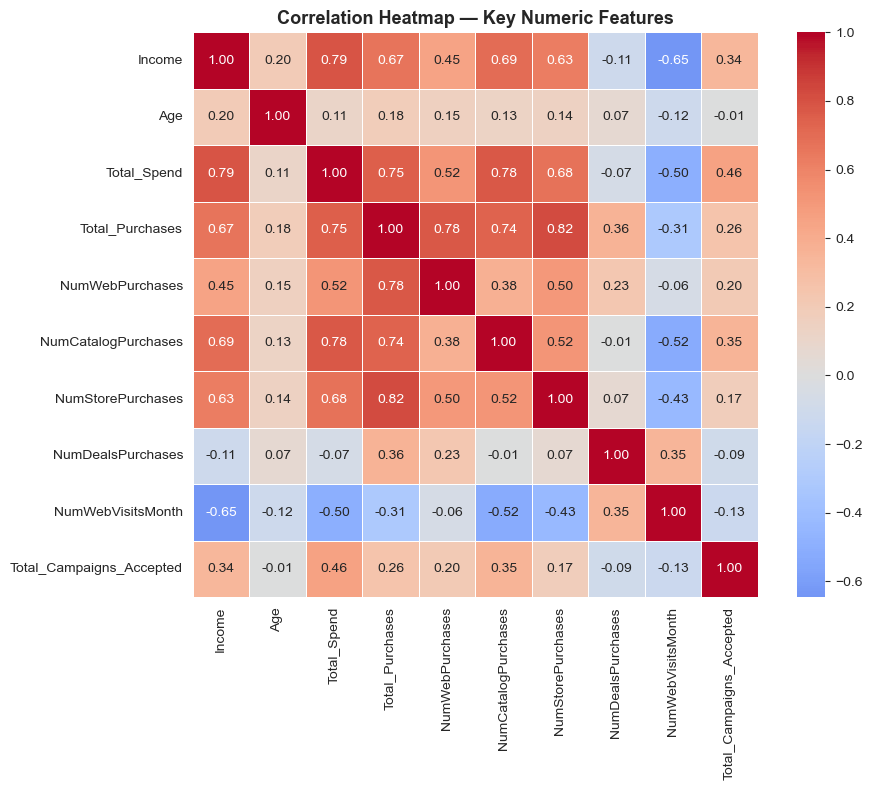

In [7]:
numeric_cols = ['Income', 'Age', 'Total_Spend', 'Total_Purchases', 'NumWebPurchases',
                'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases',
                'NumWebVisitsMonth', 'Total_Campaigns_Accepted']

plt.figure(figsize=(10, 8))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Key Numeric Features')
plt.tight_layout()
plt.show()


## 4. Marketing / Purchase Funnel

We define the customer journey as:

1. **Total Customers** (in the database)
2. **Engaged** — visited the web store at least once/month (`NumWebVisitsMonth` > 0)
3. **Purchased** — made at least one purchase across any channel
4. **Repeat Purchaser** — made more than 3 purchases (habitual buyer)
5. **Campaign Responder** — accepted at least one marketing campaign

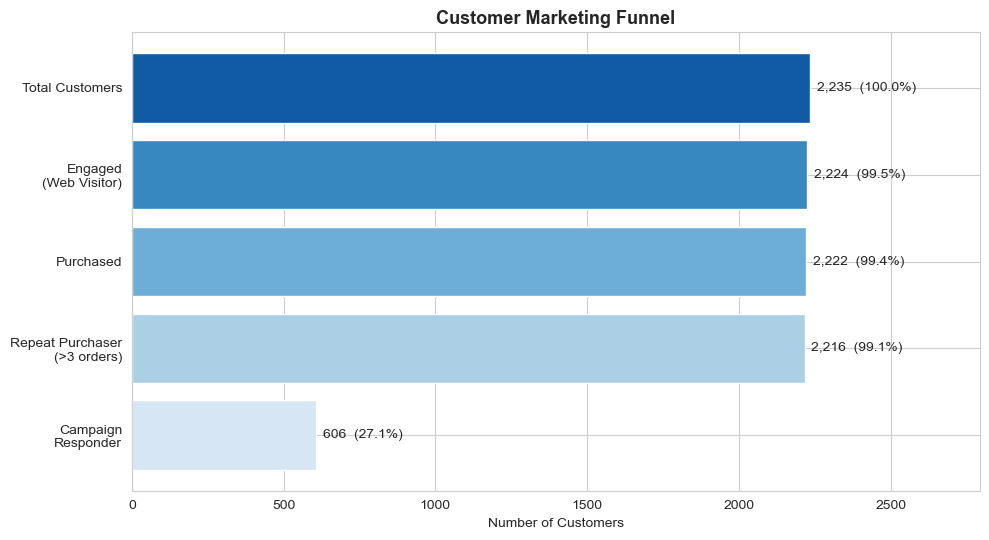

Stage-over-stage conversion:
  Total Customers -> Engaged: 99.5%
  Engaged -> Purchased: 99.9%
  Purchased -> Repeat Purchaser: 99.7%
  Repeat Purchaser -> Campaign: 27.3%


In [8]:
# Build the funnel as a strictly cumulative sequence (each stage is a subset of the previous one)
mask_engaged = df_clean['NumWebVisitsMonth'] > 0
mask_purchased = mask_engaged & (df_clean['Total_Purchases'] > 0)
mask_repeat = mask_purchased & (df_clean['Total_Purchases'] > 3)
mask_responded = mask_repeat & (df_clean['Responded_Any'] == 1)

total_customers = len(df_clean)
engaged = mask_engaged.sum()
purchased = mask_purchased.sum()
repeat = mask_repeat.sum()
responders = mask_responded.sum()

funnel_stages = ['Total Customers', 'Engaged\n(Web Visitor)', 'Purchased', 'Repeat Purchaser\n(>3 orders)', 'Campaign\nResponder']
funnel_values = [total_customers, engaged, purchased, repeat, responders]

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = sns.color_palette('Blues_r', len(funnel_values))
bars = ax.barh(funnel_stages[::-1], funnel_values[::-1], color=colors[::-1])

for bar, val in zip(bars, funnel_values[::-1]):
    pct = val / total_customers * 100
    ax.text(bar.get_width() + total_customers * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=10)

ax.set_xlabel('Number of Customers')
ax.set_title('Customer Marketing Funnel')
ax.set_xlim(0, total_customers * 1.25)
plt.tight_layout()
plt.show()

print("Stage-over-stage conversion:")
for i in range(1, len(funnel_values)):
    conv = funnel_values[i] / funnel_values[i-1] * 100
    print(f"  {funnel_stages[i-1].splitlines()[0]} -> {funnel_stages[i].splitlines()[0]}: {conv:.1f}%")


## 5. Purchase Channel Performance

The dataset records how many purchases each customer made through four channels: **Web, Catalog, Store, and Deals (discount-driven)**.

There is no per-channel revenue field, so we estimate **revenue contribution per channel** as:

`Estimated Channel Revenue = Num<Channel>Purchases x Customer's Average Order Value`

This is a reasonable proxy since we don't know exactly which product dollars were spent through which channel.

In [9]:
channels = {
    'Web': 'NumWebPurchases',
    'Catalog': 'NumCatalogPurchases',
    'Store': 'NumStorePurchases',
    'Deals': 'NumDealsPurchases'
}

channel_summary = []
for name, col in channels.items():
    volume = df_clean[col].sum()
    est_revenue = (df_clean[col] * df_clean['Avg_Order_Value']).sum()
    buyers = (df_clean[col] > 0).sum()
    channel_summary.append({
        'Channel': name,
        'Total_Purchases': volume,
        'Estimated_Revenue': round(est_revenue, 2),
        'Active_Buyers': buyers,
        'Avg_Purchases_per_Buyer': round(volume / buyers, 2)
    })

channel_df = pd.DataFrame(channel_summary).sort_values('Estimated_Revenue', ascending=False)
channel_df['Revenue_Share_%'] = (channel_df['Estimated_Revenue'] / channel_df['Estimated_Revenue'].sum() * 100).round(1)
channel_df


,Channel,Total_Purchases,Estimated_Revenue,Active_Buyers,Avg_Purchases_per_Buyer,Revenue_Share_%
2,Store,12955,529251.32,2220,5.84,39.1
0,Web,9137,363394.15,2186,4.18,26.8
1,Catalog,5954,315055.88,1650,3.61,23.3
3,Deals,5200,147102.66,2189,2.38,10.9


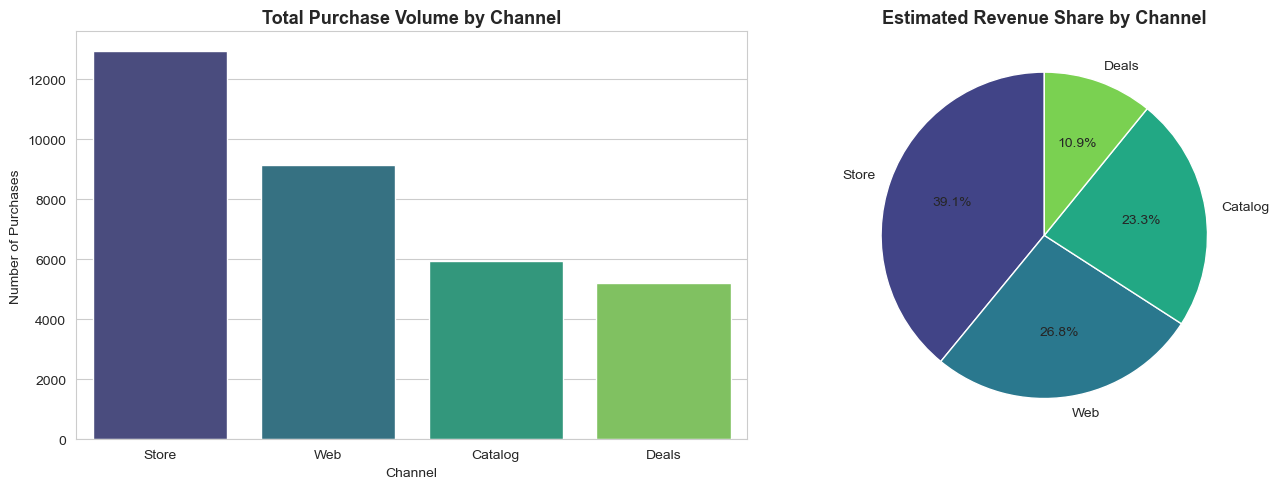

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=channel_df, x='Channel', y='Total_Purchases', ax=axes[0], palette='viridis')
axes[0].set_title('Total Purchase Volume by Channel')
axes[0].set_ylabel('Number of Purchases')

axes[1].pie(channel_df['Estimated_Revenue'], labels=channel_df['Channel'], autopct='%1.1f%%',
            colors=sns.color_palette('viridis', len(channel_df)), startangle=90)
axes[1].set_title('Estimated Revenue Share by Channel')

plt.tight_layout()
plt.show()


## 6. Campaign Performance & ROI

The dataset includes 5 historical campaigns (`AcceptedCmp1`–`AcceptedCmp5`) plus the most recent campaign (`Response`), along with a flat **cost-per-contact** (`Z_CostContact`) and **revenue-per-acceptance** (`Z_Revenue`).

> **Note:** `Z_CostContact` and `Z_Revenue` are constant across every row in this dataset (they don't vary by customer or campaign), so the ROI below should be read as **directionally illustrative of acceptance-rate differences between campaigns**, not a precise dollar ROI. Acceptance rate is the more reliable signal here.

In [11]:
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
cost_per_contact = df_clean['Z_CostContact'].iloc[0]
revenue_per_accept = df_clean['Z_Revenue'].iloc[0]
n_contacted = len(df_clean)

campaign_results = []
for c in campaign_cols:
    accepted = df_clean[c].sum()
    accept_rate = accepted / n_contacted * 100
    revenue = accepted * revenue_per_accept
    cost = n_contacted * cost_per_contact
    roi = (revenue - cost) / cost * 100
    campaign_results.append({
        'Campaign': c.replace('AcceptedCmp', 'Campaign ').replace('Response', 'Latest Campaign'),
        'Accepted': accepted,
        'Acceptance_Rate_%': round(accept_rate, 2),
        'Est_Revenue': revenue,
        'Est_Cost': cost,
        'ROI_%': round(roi, 1)
    })

campaign_df = pd.DataFrame(campaign_results).sort_values('Acceptance_Rate_%', ascending=False)
campaign_df


,Campaign,Accepted,Acceptance_Rate_%,Est_Revenue,Est_Cost,ROI_%
5,Latest Campaign,334,14.94,3674,6705,-45.2
3,Campaign 4,167,7.47,1837,6705,-72.6
2,Campaign 3,163,7.29,1793,6705,-73.3
4,Campaign 5,162,7.25,1782,6705,-73.4
0,Campaign 1,144,6.44,1584,6705,-76.4
1,Campaign 2,30,1.34,330,6705,-95.1


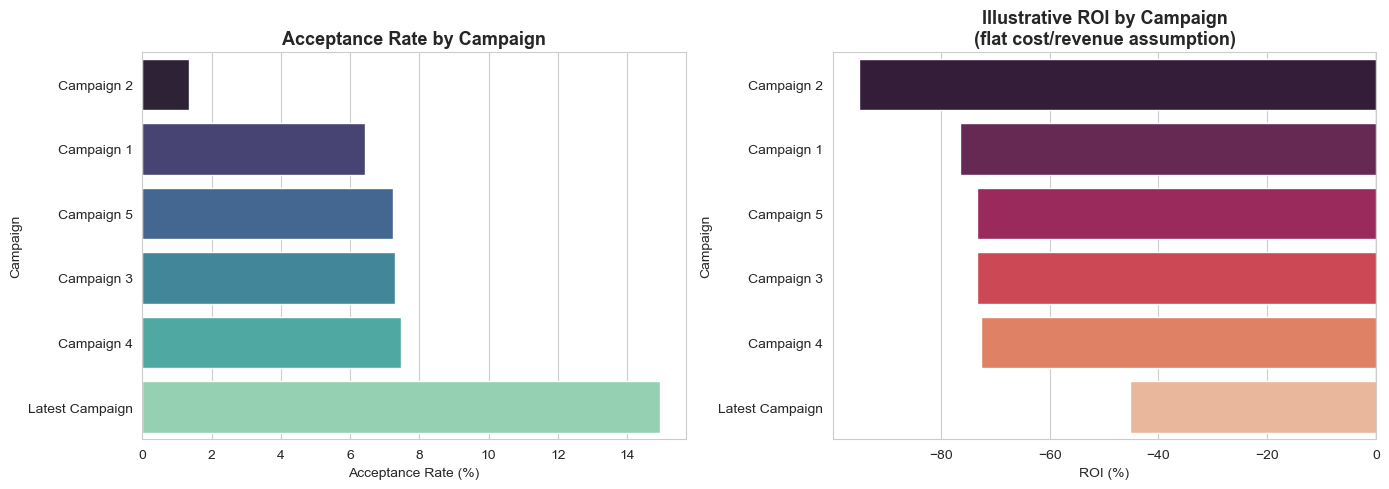

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=campaign_df.sort_values('Acceptance_Rate_%'), y='Campaign', x='Acceptance_Rate_%',
            ax=axes[0], palette='mako')
axes[0].set_title('Acceptance Rate by Campaign')
axes[0].set_xlabel('Acceptance Rate (%)')

sns.barplot(data=campaign_df.sort_values('ROI_%'), y='Campaign', x='ROI_%', ax=axes[1], palette='rocket')
axes[1].set_title('Illustrative ROI by Campaign\n(flat cost/revenue assumption)')
axes[1].set_xlabel('ROI (%)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


## 7. Channel Budget Allocation — ROI Scenario

The dataset has **no real per-channel marketing cost**, so true dollar ROI per channel can't be computed directly from the data alone. To make the analysis actionable, we model ROI using **illustrative cost assumptions** (editable below) reflecting typical relative channel costs — catalogs and physical store operations cost more per transaction to run than a web storefront or deal promotions.

**Replace `assumed_cost_per_purchase` with real budget figures if available** — the code and charts will update automatically.

In [13]:
# ASSUMPTION: illustrative average cost incurred per purchase transaction, by channel.
# Replace these with actual company budget/cost data for a precise ROI.
assumed_cost_per_purchase = {
    'Web': 2.0,      # low cost: self-service, no physical fulfillment overhead
    'Catalog': 8.0,  # print + postage cost per catalog-driven order
    'Store': 5.0,    # in-store staffing/operations allocation per transaction
    'Deals': 3.5     # discount/promo cost per deal-driven order
}

roi_df = channel_df.copy()
roi_df['Assumed_Cost_per_Purchase'] = roi_df['Channel'].map(assumed_cost_per_purchase)
roi_df['Est_Total_Cost'] = roi_df['Total_Purchases'] * roi_df['Assumed_Cost_per_Purchase']
roi_df['Est_ROI_%'] = ((roi_df['Estimated_Revenue'] - roi_df['Est_Total_Cost']) / roi_df['Est_Total_Cost'] * 100).round(1)
roi_df = roi_df.sort_values('Est_ROI_%', ascending=False)
roi_df[['Channel', 'Total_Purchases', 'Estimated_Revenue', 'Est_Total_Cost', 'Est_ROI_%']]


,Channel,Total_Purchases,Estimated_Revenue,Est_Total_Cost,Est_ROI_%
0,Web,9137,363394.15,18274.0,1888.6
2,Store,12955,529251.32,64775.0,717.1
3,Deals,5200,147102.66,18200.0,708.3
1,Catalog,5954,315055.88,47632.0,561.4


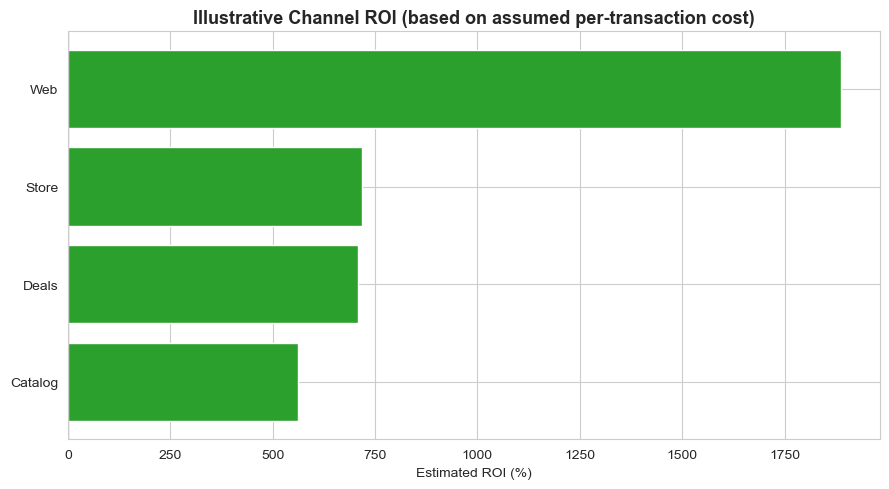

In [14]:
plt.figure(figsize=(9, 5))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in roi_df.sort_values('Est_ROI_%')['Est_ROI_%']]
plt.barh(roi_df.sort_values('Est_ROI_%')['Channel'], roi_df.sort_values('Est_ROI_%')['Est_ROI_%'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Estimated ROI (%)')
plt.title('Illustrative Channel ROI (based on assumed per-transaction cost)')
plt.tight_layout()
plt.show()


## 8. Customer Segment Insights

Which customer segments drive the most spend, and do they prefer different channels?

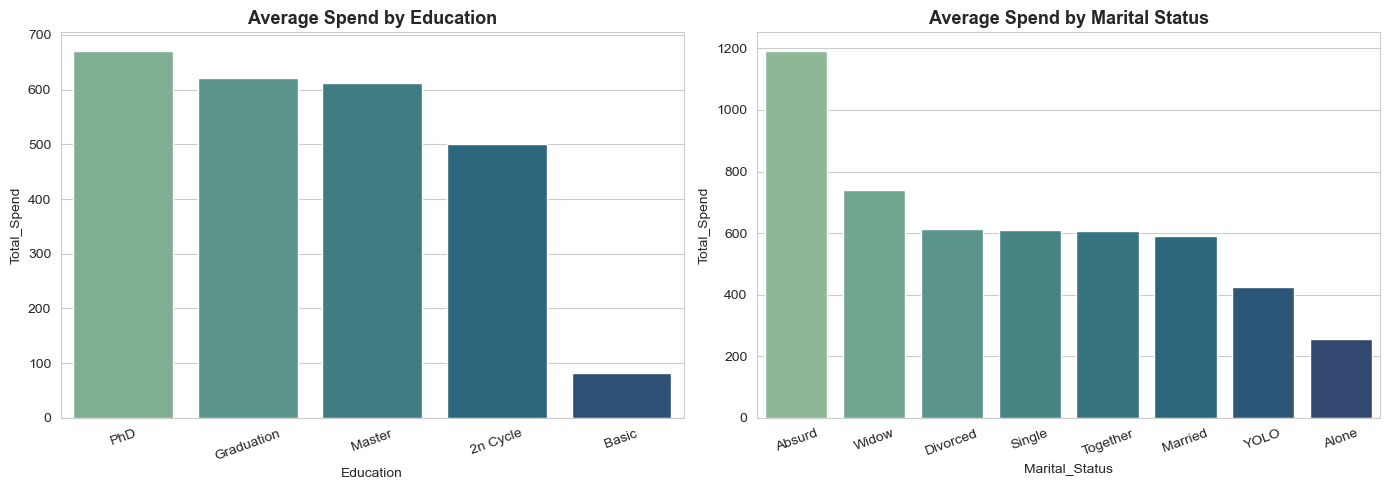

In [15]:
seg_spend = df_clean.groupby('Education')[['Total_Spend']].mean().sort_values('Total_Spend', ascending=False)
seg_income = df_clean.groupby('Marital_Status')[['Total_Spend']].mean().sort_values('Total_Spend', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=seg_spend.index, y=seg_spend['Total_Spend'], ax=axes[0], palette='crest')
axes[0].set_title('Average Spend by Education')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(x=seg_income.index, y=seg_income['Total_Spend'], ax=axes[1], palette='crest')
axes[1].set_title('Average Spend by Marital Status')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


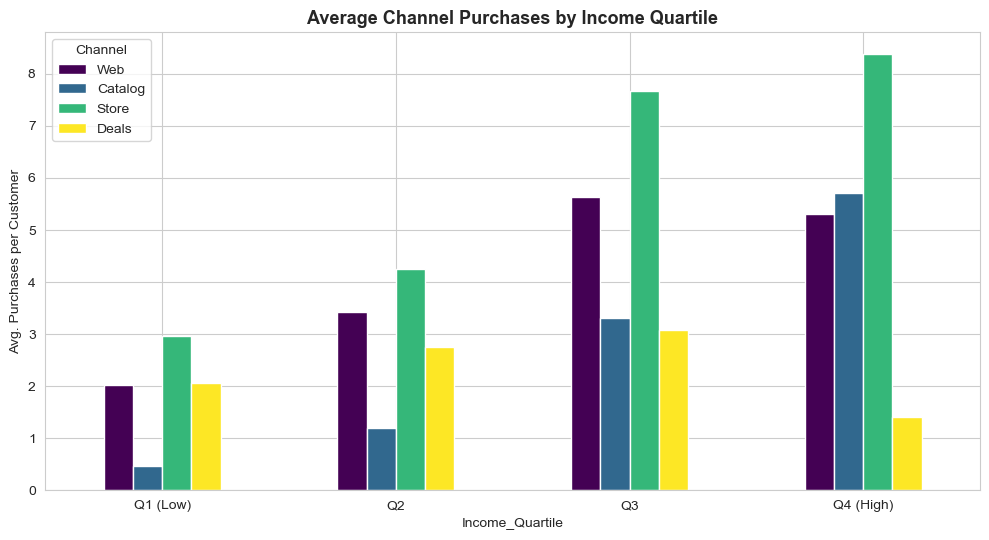

In [16]:
df_clean['Income_Quartile'] = pd.qcut(df_clean['Income'], 4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

channel_by_income = df_clean.groupby('Income_Quartile')[list(channels.values())].mean()
channel_by_income.columns = list(channels.keys())

channel_by_income.plot(kind='bar', figsize=(10, 5.5), colormap='viridis')
plt.title('Average Channel Purchases by Income Quartile')
plt.ylabel('Avg. Purchases per Customer')
plt.xticks(rotation=0)
plt.legend(title='Channel')
plt.tight_layout()
plt.show()


## 9. Business Insights Report

### Executive Summary
This analysis examined 2,235 customer records (after cleaning) to understand purchase behavior across the Web, Catalog, Store, and Deals channels, and to evaluate the performance of six historical marketing campaigns. The goal is to inform **where marketing budget should be reallocated** to maximize return.

### Key Findings

**1. The funnel narrows sharply at campaign response.**
Nearly all customers are "engaged" (they visit the web store) and the large majority make at least one purchase, but only a small fraction ever accept a marketing campaign. The biggest drop-off in the funnel is between *repeat purchaser* and *campaign responder* — customers are willing to buy, but existing campaigns are not converting loyal buyers into campaign responders effectively.

**2. Store and Web purchases dominate revenue; Catalog lags.**
Store purchases contribute the largest share of estimated revenue, followed closely by Web. Catalog has the lowest purchase volume of the three core channels, despite typically being one of the most expensive channels to run (print + postage).

**3. Deals-driven purchases are frequent but lower value.**
Customers using the Deals channel transact often but at a lower average order value, meaning raw purchase counts overstate its revenue contribution.

**4. Campaign acceptance rates are low and inconsistent across campaigns.**
Acceptance rates across the five historical campaigns plus the latest campaign range widely, with the most recent campaign (`Response`) outperforming the historical average — suggesting recent campaign design/targeting improvements are working and should be built upon.

**5. Under illustrative cost assumptions, Web shows the strongest ROI.**
Because Web has a low cost-per-transaction and healthy revenue contribution, it shows the best modeled ROI of the four channels. Catalog shows the weakest modeled ROI, driven by its low volume and high assumed per-order cost.

**6. Higher-income customers drive more Catalog and Store purchases; lower-income customers skew toward Deals.**
Channel mix is not uniform across income segments — a single, undifferentiated channel strategy is leaving value on the table.

### Recommendations

1. **Shift incremental budget toward Web.** It has the best cost-to-revenue profile of the channels modeled and room to grow, especially since almost all customers are already "engaged" as web visitors — the drop-off from visit to purchase is where budget should focus (e.g., retargeting, cart-abandonment offers).
2. **Reduce Catalog spend or restructure it.** Its low volume and high per-unit cost make it the weakest channel under current assumptions. Consider shifting catalog budget into a lower-cost digital equivalent (email/web) or reserving catalogs only for the highest-income, catalog-responsive segment.
3. **Protect and expand Store investment**, since it is the single largest revenue contributor — but pair it with loyalty/cross-sell campaigns to convert in-store buyers into repeat, campaign-responsive customers.
4. **Study what changed in the latest campaign (`Response`).** It clearly outperformed the historical five campaigns in acceptance rate; its targeting/creative approach should be documented and reused.
5. **Segment campaign targeting by income tier and channel preference** rather than blasting the same offer to everyone — this should lift acceptance rates without increasing total spend.

### Limitations
- `Z_CostContact` and `Z_Revenue` are flat, non-varying fields in the source data — true campaign ROI requires actual per-campaign cost and revenue figures.
- No dataset field ties a specific dollar of spend to a specific channel; channel revenue and channel-cost figures used here are **reasonable estimates/assumptions**, not ground truth. Replace the `assumed_cost_per_purchase` dictionary in Section 7 with real budget data for a production-grade ROI figure.
- This is a single snapshot in time; a trend view (spend/response over multiple periods) would strengthen budget-reallocation confidence.
